In [1]:
import numpy as np
from scipy.special import exp1
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from itertools import cycle

In [2]:
def theis_u(r, T, S, t):
    """
    Calculate dimensionless Theis variable (u):
        r: Radial distance(s) from well(s) [L]
        T: Transmissivity [L^2/T]
        S: Storage coefficient [-]
        t: Time since pumping started [T]

    Notes:
        - r,t can be arrays (broadcastable).

    """
    r = np.asarray(r, dtype=float)
    t = np.asarray(t, dtype=float)
    if np.any(t <= 0):
        raise ValueError("t must be > 0 for Theis solution!")
    return (r**2 * S) / (4.0 * T * t)

In [3]:
def drawdown_s(Q, T, S, r, t):
    """
    Calculate drawdown:
        Q: pumping rate (positive for extraction) [L^3/T]
        T: transmissivity [L^2/T]
        S: storage coefficient [-]
        r: radial distance(s) [L] (scalar or array)
        t: time(s) since pumping started [T] (scalar or array)
    
    Notes:
        - r,t can be arrays (broadcastable).
    
    """
    u = theis_u(r, T, S, t)
    return (Q / (4.0 * np.pi * T)) * exp1(u)

In [4]:
def ds_dr_from_theis(Q, T, S, r, t):
    """
    Calculate radial derivative ds/dr from the Theis solution in a numerically stable form:
        Q: pumping rate (positive for extraction) [L^3/T]
        T: transmissivity [L^2/T]
        S: storage coefficient [-]
        r: radial distance(s) [L] (scalar or array)
        t: time(s) since pumping started [T] (scalar or array)

    Notes: 
        - ds/dr is singular at r = 0 (1/r)
        - For r = =0, function produces NaN

    """
    r = np.asarray(r, dtype=float)
    t = np.asarray(t, dtype=float)
    u = theis_u(r, T, S, t)
    out = - (Q / (2.0 * np.pi * T)) * (np.exp(-u) / r)

    # mark undefined at r==0
    if out.shape == ():
        if r == 0:
            return np.nan
    else:
        out = np.array(out, copy=True)
        out[r == 0] = np.nan
    return out

In [5]:
def radial_flux_qr(Q, T, S, r, t):
    """
    Calculate specific radial Darcy flux:
        Q: pumping rate (positive for extraction) [L^3/T]
        T: transmissivity [L^2/T]
        S: storage coefficient [-]
        r: radial distance(s) [L] (scalar or array)
        t: time(s) since pumping started [T] (scalar or array)
    
    Notes:
        - q_r has 1/r singularity at r = 0
    """
    r = np.asarray(r, dtype=float)
    u = theis_u(r, T, S, t)
    out = (Q / (2.0 * np.pi)) * (np.exp(-u) / r)
    if out.shape == ():
        if r == 0:
            return np.nan
    else:
        out = np.array(out, copy=True)
        out[r == 0] = np.nan
    return out

In [6]:
def boundary_flux(Q, T, S, r, t):
    """
    Calculate boundary flux:
        Q: pumping rate (positive for extraction) [L^3/T]
        T: transmissivity [L^2/T]
        S: storage coefficient [-]
        r: radial distance(s) [L] (scalar or array)
        t: time(s) since pumping started [T] (scalar or array)
    
    """
    u = theis_u(r, T, S, t)
    return Q * np.exp(-u)


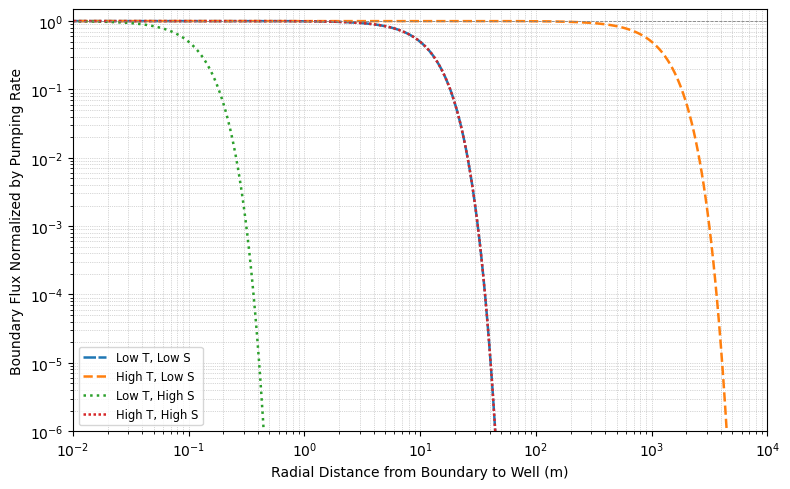

In [ ]:
# test case

# parameter sets tuple (label, Q [m^3/s], T [m^2/s], S [-])
param_sets = [
("Low T, Low S",        0.50, 1e-7, 1e-5),
("High T, Low S",       0.50, 1e-3, 1e-5),
("Low T, High S",       0.50, 1e-7, 1e-1),
("High T, High S",      0.50, 1e-3, 1e-1),
# ("High T, High S",      0.50, 1e-3, 1e-1),
]

# time
t = 3600.0  # seconds (1 hour)

# radii including very small values to inspect r->0 behaviour and out to large distances
r = np.logspace(-6, 4, 600)  # from 1e-6 m to 1e4 m

# plot boundary flux for each parameter set

style_map = {
    "Low T, Low S":  (0, (5, 1)),   # long dash / short gap
    "High T, Low S": '--',          # dashed
    "Low T, High S": ':' ,          # dotted
    "High T, High S": (0, (1, 1)),  # dense short dash (alternating)
}

colors = plt.get_cmap("tab10").colors
color_cycle = cycle(colors)

plt.figure(figsize=(8,5))

for (label, Q, T, S), c in zip(param_sets, color_cycle):
    Qb_vals = boundary_flux(Q, T, S, r, t)
    ls = style_map.get(label, '--')
    plt.loglog(r, Qb_vals / Q, label=label, linewidth=1.8,
               linestyle=ls, color=c)  # no marker

# horizontal reference
plt.hlines(1.0, r[0], r[-1], linestyles='--', linewidth=0.6, colors='gray')

plt.xlabel("Radial Distance from Boundary to Well (m)")
plt.ylabel("Boundary Flux Normalized by Pumping Rate")
plt.grid(True, which="both", ls=":", linewidth=0.5)
plt.legend(fontsize="small", loc="lower left")
plt.xlim(1e-2, 1e4)
plt.ylim(1e-6, 1.5)
plt.tight_layout()
plt.show()